# Headers

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import sys
import os

import comet_ml
import json

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()
    
parent_dir = os.path.join(current_dir, '..', '..', '..')
sys.path.insert(0, parent_dir)
    
    
from analysis_scripts.config import CFG


CFG.seed_all(CFG.seed)
sns.set_theme(style='ticks')

CUDA available: False
Use CPU, 
Number of CPUs: 12


# Load preprocessed data

In [2]:
train_df = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/proc_df_1.csv').drop('Unnamed: 0', axis=1)
test_df = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/proc_df_2.csv').drop('Unnamed: 0', axis=1)

assert not train_df.isna().sum().sum(), 'Train, data containes NaNs!!'
assert not test_df.isna().sum().sum(), 'Test, data containes NaNs!!'

# Prepare Data

Exclude variables that affect background shape: 
* is_mass_window,
* mass_Lc,
* mass_pt_correlation
* ?Mt_Lc?

In [3]:
# Comet logger
# experiment = comet_ml.Experiment(
#     project_name="SPD ML",
#     workspace="artem-smirnov",
#     api_key="yyKk8vacVuy8dbttSCIgF2iQO"
# )

features_list = CFG.feature_set_1

try:
    experiment.set_name('feature_set_1, params_xgboost_1')
    formatted_text = json.dumps({"feature_names": features_list}, indent=2)
    experiment.log_text(text=formatted_text)
except NameError:
    pass

train_df = train_df[features_list + [CFG.target_name, 'mass_Lc']].copy()
test_df = test_df[features_list + [CFG.target_name, 'mass_Lc']].copy()

x = train_df.drop(['tag', 'mass_Lc'], axis=1).copy()
y = train_df['tag'].map({'Sig': 1, 'Bg': 0}).copy()

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, shuffle=True, stratify=y, random_state=CFG.seed)

x_test = test_df.drop(['tag', 'mass_Lc'], axis=1).copy()
y_test = test_df['tag'].map({'Sig': 1, 'Bg': 0}).copy()

In [4]:
# Feature encoding
if features_list == CFG.feature_set_1:
    cols_to_encode = [
        'highest_pt_daughter', 'highest_momentum_daughter', 'highest_OA_daughter',
        'highest_eta_daughter', 'highest_dca_Lc_daughter', 'highest_dca_PV_daughter',
    ]
elif features_list == CFG.feature_set_2:
    cols_to_encode = [
        'highest_momentum_daughter',
        'highest_eta_daughter', 'highest_dca_Lc_daughter', 'highest_dca_PV_daughter',
    ]
elif features_list == CFG.feature_set_3:
    cols_to_encode = []

preprocessor = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(sparse_output=False, dtype=int), cols_to_encode)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

preprocessor.fit(x_train)
x_train_encoded = preprocessor.transform(x_train)
x_val_encoded = preprocessor.transform(x_val)
x_test_encoded = preprocessor.transform(x_test)

feature_names = preprocessor.get_feature_names_out()

x_train = pd.DataFrame(x_train_encoded, columns=feature_names, index=x_train.index)
x_val = pd.DataFrame(x_val_encoded, columns=feature_names, index=x_val.index)
x_test = pd.DataFrame(x_test_encoded, columns=feature_names, index=x_test.index)


# Drop excluded columns
if features_list == CFG.feature_set_2:
    
    features_to_drop = [
        'highest_momentum_daughter_P_pip', 'highest_momentum_daughter_P_p',
        'highest_eta_daughter_eta_pip', 'highest_dca_PV_daughter_dist_pip_PV_xy',
        'highest_dca_Lc_daughter_dist_p_Lc_xy',
    ]

    x_train = x_train.drop(columns=features_to_drop)
    x_val = x_val.drop(columns=features_to_drop)
    x_test = x_test.drop(columns=features_to_drop)

In [5]:
for feature in features_list:
    
    if feature in CFG.cols_to_log_transform:
        pass
        # x_train[feature + '_log'] = np.log1p(x_train[feature])
        # x_val[feature + '_log'] = np.log1p(x_val[feature])
        # x_test[feature + '_log'] = np.log1p(x_test[feature])
    
    if feature in CFG.continual_features:
        pass
        # x_train[feature + '_pct'] = x_train[feature].rank(pct=True)
        # x_val[feature + '_pct'] = x_val[feature].rank(pct=True)
        # x_test[feature + '_pct'] = x_test[feature].rank(pct=True)
        
        # x_train[feature + '_bin'] = pd.cut(x_train[feature], bins=10, labels=False)
        # x_val[feature + '_bin'] = pd.cut(x_train[feature], bins=10, labels=False)
        # x_test[feature + '_bin'] = pd.cut(x_train[feature], bins=10, labels=False)

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(x_train)
x_train = pd.DataFrame(scaler.transform(x_train), columns=x_train.columns, index=x_train.index)
x_val = pd.DataFrame(scaler.transform(x_val), columns=x_val.columns, index=x_val.index)
x_test = pd.DataFrame(scaler.transform(x_test), columns=x_test.columns, index=x_test.index)

# sklearn LogisticRegression

### Feature Importance

In [ ]:
params={}
params.update({
    'penalty': 'l2',
    'solver': 'newton-cholesky',
    'fit_intercept': True,
    'verbose': 0,
    'n_jobs': -1,
    'random_state': CFG.seed
})

model = LogisticRegression(**params)
model.fit(x_train, y_train)

feature_names = x_train.columns
importance_scores = np.abs(model.coef_).flatten()

feature_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance_scores
}).sort_values('importance', ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(8, 9))

sns.barplot(
    data=feature_df,
    x='importance',
    y='feature',
    palette='viridis_r',
    orient='h'
)

plt.title(f'Feature Importances - LGBM Classifier', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
# plt.savefig('test.pdf', bbox_inches='tight', pad_inches=0.1, dpi=300)
plt.show()

### Cross-validation

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression


params={}
params.update({
    'penalty': 'l2',
    'solver': 'newton-cholesky',
    'fit_intercept': True,
    'verbose': 0,
    'n_jobs': 6,
    'random_state': CFG.seed
})

model = LogisticRegression(**params)

try:
    experiment.log_parameters(params)
except NameError:
    pass

scoring = {
    'roc_auc': 'roc_auc'
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=CFG.seed)
split_generator = skf.split(x_train, y_train)

cv_results = cross_validate(
    estimator=model,
    X=x,
    y=y,
    cv=split_generator,
    scoring=scoring,
    return_train_score=True,
    return_estimator=True,
    verbose=3,
    n_jobs=6
)

train_scores = cv_results['train_roc_auc']
val_scores = cv_results['test_roc_auc']
models = cv_results['estimator']

try:
    experiment.log_metrics({
        'cv_train_mean_roc_auc':  train_scores.mean(),
        'cv_val_mean_roc_auc':  val_scores.mean()
    })
except NameError:
    pass

print(f'\n\nMean CV train score: {train_scores.mean():0.3f}')
print(f'Mean CV val score: {val_scores.mean():0.3f}')

### Single Model Estimation

#### Create model

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report


params = {}
params.update({
    'penalty': 'l2',
    'solver': 'newton-cholesky',
    'fit_intercept': True,
    'verbose': 0,
    'n_jobs': -1,
    'random_state': CFG.seed
})

model = LogisticRegression(**params)
model.fit(x_train, y_train)

# Evaluate on train set
y_pred_train = model.predict(x_train)
y_pred_proba_train = model.predict_proba(x_train)[:, 1]

print(f'\n{'#'*60}')
print(f"Train set performance:\n")
print(classification_report(y_true=y_train, y_pred=y_pred_train))
print(f"ROC-AUC: {roc_auc_score(y_train, y_pred_proba_train):.4f}")

try:
    experiment.log_metric(name='classification_report', value=classification_report(y_train, y_pred_proba_train))
    experiment.log_metric(name='roc_auc_score', value=roc_auc_score(y_train, y_pred_proba_train))
except NameError:
    pass

# Evaluate on val set
y_pred_val = model.predict(x_val)
y_pred_proba_val = model.predict_proba(x_val)[:, 1]

print(f'\n{'#'*60}')
print(f"Val set performance:\n")
print(classification_report(y_true=y_val, y_pred=y_pred_val))
print(f"ROC-AUC: {roc_auc_score(y_val, y_pred_proba_val):.4f}")

try:
    experiment.log_metric(name='classification_report', value=classification_report(y_val, y_pred_proba_val))
    experiment.log_metric(name='roc_auc_score', value=roc_auc_score(y_val, y_pred_proba_val))
except NameError:
    pass

# Evaluate on test set
y_pred_test = model.predict(x_test)
y_pred_proba_test = model.predict_proba(x_test)[:, 1]

print(f'\n{'#'*60}')
print(f"Test set performance:\n")
print(classification_report(y_true=y_test, y_pred=y_pred_test))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_test):.4f}")

try:
    experiment.log_metric(name='classification_report', value=classification_report(y_test, y_pred_proba_test))
    experiment.log_metric(name='roc_auc_score', value=roc_auc_score(y_test, y_pred_proba_test))
except NameError:
    pass


############################################################
Train set performance:

              precision    recall  f1-score   support

           0       0.94      0.95      0.95    177607
           1       0.84      0.83      0.84     59485

    accuracy                           0.92    237092
   macro avg       0.89      0.89      0.89    237092
weighted avg       0.92      0.92      0.92    237092

ROC-AUC: 0.9688

############################################################
Val set performance:

              precision    recall  f1-score   support

           0       0.94      0.95      0.95     44402
           1       0.84      0.83      0.83     14871

    accuracy                           0.92     59273
   macro avg       0.89      0.89      0.89     59273
weighted avg       0.92      0.92      0.92     59273

ROC-AUC: 0.9686

############################################################
Test set performance:

              precision    recall  f1-score   support

    

#### Classifier Calibration

#### Optimize threshold

In [8]:
from analysis_scripts.estimate_scripts import signal_estimates
from sklearn.metrics import f1_score, precision_score


# From data_explore section
sig_eff_presel = 0.7241826749529263
bg_eff_presel = 0.49130648841423924

#---------------
# Get raw df
data_oc_df = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/analysed_signal_2.csv', usecols=['mass_Lc', 'true_decay'])
data_mb_df = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/analysed_background_2.csv', usecols=['mass_Lc', 'true_decay'])

mass_mask = (data_oc_df['mass_Lc'] > CFG.mass_interval[0]) \
            & ( data_oc_df['mass_Lc'] < CFG.mass_interval[1]) \
            & (data_oc_df['true_decay'] == 1)

data_oc_df = data_oc_df[mass_mask]
data_oc_df['tag'] = 'Sig'

mass_mask = (data_mb_df['mass_Lc'] > CFG.mass_interval[0]) & ( data_mb_df['mass_Lc'] < CFG.mass_interval[1])

data_mb_df = data_mb_df[mass_mask]
data_mb_df['tag'] = 'Bg'

raw_df = pd.concat([data_oc_df, data_mb_df], axis=0).reset_index(drop=True)
#---------------

pred_df = pd.DataFrame({
    'y_true': y_test,
    'y_pred_proba': y_pred_proba_test
})

thresholds = np.arange(0.1, 1, 0.05)
f1_scores = []
precision_scores = []
s_over_b = []

for threshold in thresholds:
    
    signal_counts_after = pred_df.loc[(pred_df.y_pred_proba >= threshold) & (pred_df.y_true == 1), 'y_true'].count()
    signal_counts_before = pred_df.loc[pred_df.y_true == 1, 'y_true'].count()
    background_counts_after = pred_df.loc[(pred_df.y_pred_proba >= threshold) & (pred_df.y_true == 0), 'y_true'].count()
    background_counts_before = pred_df.loc[pred_df.y_true == 0, 'y_true'].count()

    signal_eff_ML = signal_counts_after / signal_counts_before
    background_eff_ML = background_counts_after / background_counts_before

    total_sig_efficiency = sig_eff_presel * signal_eff_ML
    total_bg_suppression = bg_eff_presel * background_eff_ML

    sig_mass_distr = raw_df.loc[raw_df['tag'] == 'Sig', 'mass_Lc']
    bg_mass_distr = raw_df.loc[raw_df['tag'] == 'Bg', 'mass_Lc']

    overall_s_b, *_ = signal_estimates(
        sig_mass_distr=sig_mass_distr,
        bg_mass_distr=bg_mass_distr,
        have_sig_events=CFG.have_sig_events_2 / total_sig_efficiency, 
        have_bg_events=CFG.have_bg_events_2 / total_bg_suppression,
        mass_interval=CFG.mass_interval, 
        visualization=False,
        verbose=False
    )
    
    f1_scores.append(f1_score(y_test, np.where(y_pred_proba_test > threshold, 1, 0)))
    precision_scores.append(precision_score(y_test, np.where(y_pred_proba_test > threshold, 1, 0)))
    s_over_b.append(overall_s_b)
    
res_df = pd.DataFrame({
    'threshold': thresholds,
    'f1_score': f1_scores,
    'precision': precision_scores,
    's_over_b': s_over_b
})
res_df

,threshold,f1_score,precision,s_over_b
0,0.10,0.719538,0.571194,0.000091
1,0.15,0.751452,0.617771,0.000110
2,0.20,0.772696,0.653551,0.000128
3,0.25,0.788128,0.683659,0.000147
4,0.30,0.797834,0.708404,0.000165
5,0.35,0.805322,0.731745,0.000186
6,0.40,0.809677,0.752627,0.000207
7,0.45,0.811677,0.773314,0.000232
8,0.50,0.810478,0.791391,0.000258
9,0.55,0.806982,0.809636,0.000290


In [9]:
optimal_threshold = 0.5

#### Physics Evaluation

In [10]:
from analysis_scripts.estimate_scripts import signal_estimates

threshold = optimal_threshold

pred_df = pd.DataFrame({
    'y_true': y_test,
    'y_pred_proba': y_pred_proba_test
})

signal_counts_after = pred_df.loc[(pred_df.y_pred_proba >= threshold) & (pred_df.y_true == 1), 'y_true'].count()
signal_counts_before = pred_df.loc[pred_df.y_true == 1, 'y_true'].count()
background_counts_after = pred_df.loc[(pred_df.y_pred_proba >= threshold) & (pred_df.y_true == 0), 'y_true'].count()
background_counts_before = pred_df.loc[pred_df.y_true == 0, 'y_true'].count()

signal_eff_ML = signal_counts_after / signal_counts_before
background_eff_ML = background_counts_after / background_counts_before

total_sig_efficiency = sig_eff_presel * signal_eff_ML
total_bg_suppression = bg_eff_presel * background_eff_ML

try:
    experiment.log_metrics({
        'signal_eff_ML': signal_eff_ML,
        'background_eff_ML': background_eff_ML
    })
except NameError:
    pass

print(f'ML signal efficiency: {signal_eff_ML}')
print(f'ML background efficiency: {background_eff_ML}')
print(f'Total signal efficiency: {total_sig_efficiency}')
print(f'Total background efficiency: {total_bg_suppression}')

sig_mass_distr = raw_df.loc[raw_df['tag'] == 'Sig', 'mass_Lc']
bg_mass_distr = raw_df.loc[raw_df['tag'] == 'Bg', 'mass_Lc']

_ = signal_estimates(
    sig_mass_distr=sig_mass_distr,
    bg_mass_distr=bg_mass_distr,
    have_sig_events=CFG.have_sig_events_2 / total_sig_efficiency, 
    have_bg_events=CFG.have_bg_events_2 / total_bg_suppression,
    mass_interval=CFG.mass_interval, 
    visualization=False,
    verbose=True
)


ML signal efficiency: 0.830508702915342
ML background efficiency: 0.058365688876756805
Total signal efficiency: 0.6014400140489176
Total background efficiency: 0.02867544164591741

SUMMARY STATISTICS
Total Signal Events: 12600647
Total Background Events: 48793536691
Total Signal Events Unscaled: 102499
Total Background Events Unscaled: 566687
Overall S/B Ratio: 0.000258
Overall S/sqrt(S+B) Significance: 57.04


#### Background shape check

KS-test: distributions are identical, (alpha=0.05, p_value=0.253)


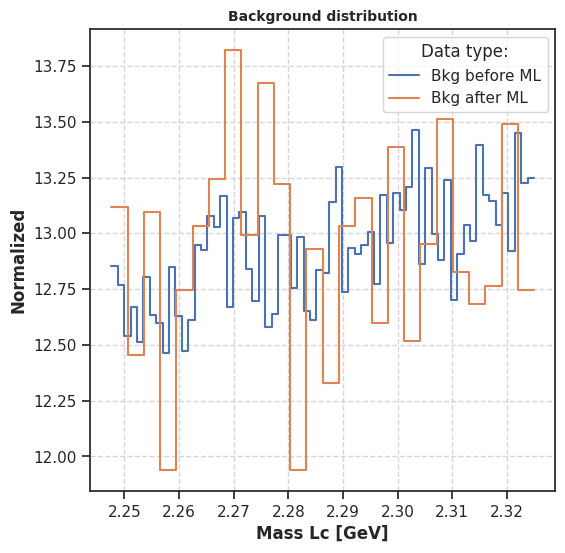

In [11]:
from scipy import stats


threshold = optimal_threshold
alpha = 0.05

df = test_df[['mass_Lc']].copy()
df['y_true'] = y_test
df['y_pred_proba'] = y_pred_proba_test

bkg_before_ML = df.loc[df.y_true == 0, 'mass_Lc']
bkg_after_Ml = df.loc[(df.y_pred_proba >= threshold) & (df.y_true == 0), 'mass_Lc']

# kolmogorov-Smirnov test
_, p_value = stats.ks_2samp(bkg_before_ML, bkg_after_Ml, alternative='two-sided')

try:
    experiment.log_metric(name='KS-test p-value', value=p_value)
except NameError:
    pass

if p_value >= alpha:
    print(f'KS-test: distributions are identical, ({alpha=}, {p_value=:0.3f})')
else:
    print(f'KS-test: distributions are different, ({alpha=}, {p_value=:0.3f})')


fig, ax = plt.subplots(figsize=(6, 6))

sns.histplot(
    data=bkg_before_ML,
    label='Bkg before ML',
    element='step',
    fill=False,
    stat='density',
    # alpha=0.8,
    ax=ax
)

sns.histplot(
    data=bkg_after_Ml,
    label='Bkg after ML',
    element='step',
    fill=False,
    stat='density',
    # alpha=0.8,
    ax=ax
)

plt.legend(title="Data type:", loc= "best")

ax.set_title('Background distribution', fontsize=10, fontweight='bold')
ax.set_xlabel('Mass Lc [GeV]', fontweight='bold')
ax.set_ylabel('Normalized', fontweight='bold')
ax.grid(True, alpha=0.8, linestyle='--')

try:
    experiment.log_figure(
        figure_name=f"Bkg distr ML",
        figure=plt.gcf()
    )
except NameError:
    pass

plt.show()

# End experiment log

In [ ]:
try:
    experiment.end()
except NameError:
    pass